## Setup

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy


In [4]:
notes = pd.read_parquet('~/Documents/GitHub/494-user-trajectories/students/ryder/notes-20240501-20240531.parquet')
ratings = pd.read_parquet('~/Documents/GitHub/494-user-trajectories/students/ryder/ratings-20240501-20240531.parquet')
party = pd.read_csv('~/Documents/GitHub/494-user-trajectories/students/ryder/database_replication.csv')

In [5]:
party = party.replace({'party': {'republican': -1, 'democrat': 1, 'unknown': np.nan}})
party.head(10)

/var/folders/14/04j_x_597gg_sc6gcvkrz1wr0000gp/T/ipykernel_43327/3990733836.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  party = party.replace({'party': {'republican': -1, 'democrat': 1, 'unknown': np.nan}})


,Unnamed: 0,note_id,note_published_helpful,tweet_author_id,party,party_barbera,party_mosleh,party_gpt,log_followers,log_tweet,verified,tweet_id,topic,politics,health,science,economy
0,0,1783179305159200982,0,1074480192,-1.0,republican,republican,unknown,15.110518,10.074158,1.0,1783159712986382830,politics,True,False,False,False
1,1,1783181538789605871,0,1221462414744596483,1.0,democrat,republican,democrat,13.407987,11.571043,1.0,1783171851818021181,politics,True,False,False,False
2,2,1783182562279494134,0,1291802729438945280,NaN,unknown,unknown,unknown,10.792633,7.657283,1.0,1783154445682979015,politics,True,False,False,False
3,3,1780256247847248236,0,185809250,1.0,democrat,democrat,unknown,11.642374,11.014852,0.0,1779984568143282686,science,False,False,True,False
4,4,1701837464359624879,0,890061634181373952,-1.0,republican,republican,unknown,14.037493,9.487745,1.0,1701643915659731323,politics,True,False,False,False
5,5,1763005074870259781,0,15448383,-1.0,democrat,republican,republican,15.172827,14.061444,1.0,1762789289035751782,politics,True,True,False,False
6,6,1764592373097722103,0,1468707946016219141,NaN,unknown,unknown,unknown,10.010187,9.663643,0.0,1764354551086288946,other,False,False,False,False
7,7,1653518980357967873,0,918723043798560768,NaN,unknown,unknown,unknown,10.907221,11.048156,1.0,1653295426697846784,other,False,False,False,False
8,8,1671604373598900225,0,17158189,1.0,democrat,democrat,unknown,12.222054,11.158890,0.0,1671531030530883584,other,False,False,False,False
9,9,1763035751002808656,0,1058520120,1.0,democrat,democrat,unknown,13.487619,9.447860,1.0,1762967617764004242,politics,True,True,False,False


In [6]:
notes.head()

,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAtDt,noteCreatedAtDt,ratingCreatedAtDt,helpfulnessLevel,fromNotification,noteFinalRatingStatus,noteFinalIntercept,noteFinalFactor
0,1795373016215327101,1795084317133025630,46BEE7BDF0D74F67A6FB96A89554FAADC98D1C08A97888...,F6700CE6C398D88F68989BD0B4936602C790E4F7DAA7C6...,2024-05-27 13:27:06.915,2024-05-28 08:34:18.142,2024-05-30 00:14:51.014,SOMEWHAT_HELPFUL,False,CURRENTLY_RATED_HELPFUL,0.449701,-0.172285
1,1794533810723492332,1794325036469506252,E57589E18ACF953A30920C3CFECAC27DC5823B4C0D6984...,None,2024-05-25 11:10:00.298,NaT,2024-05-26 10:17:57.926,HELPFUL,False,CURRENTLY_RATED_NOT_HELPFUL,-0.118752,0.028724
2,1794234926071529505,1794132104902512852,3A4F48380746ECBCF247F6B984F19C5D12104A444263F1...,29B9492DE7045B4DDF4F7BB953C4FB3437C371D2BA372C...,2024-05-24 22:23:21.828,2024-05-25 05:11:56.302,2024-05-27 12:32:37.248,HELPFUL,False,CURRENTLY_RATED_HELPFUL,0.481177,-0.097937
3,1795529392262631789,1795364492064202867,3A4F48380746ECBCF247F6B984F19C5D12104A444263F1...,None,2024-05-28 08:00:25.824,NaT,2024-05-31 10:04:27.233,HELPFUL,False,CURRENTLY_RATED_HELPFUL,0.484249,0.042055
4,1795600864155197800,1795492798986408332,C5BB45A76FD26CA3A6003E50FE3C6D086F4F4E8B44E244...,7F16863BE3FB87264952B6B64F80825EDA9544AAAC92BB...,2024-05-28 16:30:16.578,2024-05-28 23:39:41.322,2024-05-29 16:18:50.805,SOMEWHAT_HELPFUL,False,CURRENTLY_RATED_HELPFUL,0.432479,-0.026333


In [7]:
ratings.head()

,noteAuthorParticipantId,noteId,tweetId,classification,summary,noteFinalRatingStatus,noteFinalIntercept,noteFinalFactor
0,AE392472D289E0D7728EED0EBDCEDCA116B415EC305276...,1790028118293467340,1.789931e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,Das Bundesamt präsentierte eine Vielzahl von B...,NEEDS_MORE_RATINGS,0.173358,-0.630036
1,09AB0CDEA3F716BC1833EAFAD0F3DF975123175E52D8D2...,1777068928692637834,1.775209e+18,NOT_MISLEADING,It isn’t known if by “history” he’s referring ...,NEEDS_MORE_RATINGS,0.027390,0.515722
2,43147E26944271986AB001D4D545EBB9E19C7DD37AA78C...,1682287551766298624,1.680854e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,This video has nothing to do with the Kerch Br...,NEEDS_MORE_RATINGS,0.073005,0.372383
3,None,1789327714673209371,NaN,None,None,NEEDS_MORE_RATINGS,0.275326,0.014137
4,46AFC1EFCB8EBC0BF2785B048A63D9FF9C5F95C926D899...,1792891972048547943,1.792834e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,資産家等を騙る詐欺が横行しており、 公釈(コミュニティノート)が必要です ○記事 ...,NEEDS_MORE_RATINGS,0.219755,0.197646


In [8]:
notes_party = notes.merge(party, left_on='noteId', right_on='note_id')
notes_party.head()

,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAtDt,noteCreatedAtDt,ratingCreatedAtDt,helpfulnessLevel,fromNotification,noteFinalRatingStatus,...,party_gpt,log_followers,log_tweet,verified,tweet_id,topic,politics,health,science,economy
0,1794234926071529505,1794132104902512852,3A4F48380746ECBCF247F6B984F19C5D12104A444263F1...,29B9492DE7045B4DDF4F7BB953C4FB3437C371D2BA372C...,2024-05-24 22:23:21.828,2024-05-25 05:11:56.302,2024-05-27 12:32:37.248,HELPFUL,False,CURRENTLY_RATED_HELPFUL,...,unknown,12.084831,10.923255,1.0,1794132104902512852,other,False,False,False,False
1,1795529392262631789,1795364492064202867,3A4F48380746ECBCF247F6B984F19C5D12104A444263F1...,None,2024-05-28 08:00:25.824,NaT,2024-05-31 10:04:27.233,HELPFUL,False,CURRENTLY_RATED_HELPFUL,...,democrat,14.918422,9.299450,1.0,1795364492064202867,other,False,False,False,False
2,1795600864155197800,1795492798986408332,C5BB45A76FD26CA3A6003E50FE3C6D086F4F4E8B44E244...,7F16863BE3FB87264952B6B64F80825EDA9544AAAC92BB...,2024-05-28 16:30:16.578,2024-05-28 23:39:41.322,2024-05-29 16:18:50.805,SOMEWHAT_HELPFUL,False,CURRENTLY_RATED_HELPFUL,...,unknown,11.564369,10.140061,1.0,1795492798986408332,science,False,False,True,False
3,1785504509424554406,1785345111640986045,9DE991B56C65F11A1703B4B6236D48D75E135502104D64...,41B45A48BAF1EB9AAEC2BE5F9EA4ED8ED6775FBC951FFF...,2024-04-30 16:26:59.380,2024-05-01 03:00:22.773,2024-05-01 19:25:33.859,NOT_HELPFUL,False,CURRENTLY_RATED_HELPFUL,...,republican,13.329989,9.885578,1.0,1785345111640986045,other,False,False,False,False
4,1796225083310260479,1796217517859303915,9DE991B56C65F11A1703B4B6236D48D75E135502104D64...,82DFE8A45E56FDCA96B074AB24CECF647169038ED99C21...,2024-05-30 16:30:03.022,2024-05-30 17:00:06.769,2024-05-30 17:03:59.741,SOMEWHAT_HELPFUL,False,NEEDS_MORE_RATINGS,...,republican,13.810563,10.025263,1.0,1796217517859303915,health,False,True,False,False


In [9]:
ratings_party = ratings.merge(party, left_on='noteId', right_on='note_id')
ratings_party.head()

,noteAuthorParticipantId,noteId,tweetId,classification,summary,noteFinalRatingStatus,noteFinalIntercept,noteFinalFactor,Unnamed: 0,note_id,...,party_gpt,log_followers,log_tweet,verified,tweet_id,topic,politics,health,science,economy
0,43147E26944271986AB001D4D545EBB9E19C7DD37AA78C...,1682287551766298624,1.680854e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,This video has nothing to do with the Kerch Br...,NEEDS_MORE_RATINGS,0.073005,0.372383,39425,1682287551766298624,...,unknown,7.100027,8.943506,1.0,1680853788930834432,other,False,False,False,False
1,37AD81DBA55B02FD2BB7175E12C8ABAE2F632C4F52375F...,1781707174986547416,1.781668e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,Ministry of Railways is trying to mislead peop...,CURRENTLY_RATED_HELPFUL,0.522933,-0.200378,14707,1781707174986547416,...,unknown,15.972264,13.436999,1.0,1781668094852595736,science,False,False,True,False
2,800DBAAA5E49D8D989D1530CFB044C5AC57D4B382460F8...,1786484395236294934,1.786458e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,This was not said by Tesla Board Of Directors ...,NEEDS_MORE_RATINGS,0.234975,0.362661,141048,1786484395236294934,...,unknown,6.588926,8.461680,1.0,1786457583085044044,economy,False,False,True,True
3,13B9C99438A7ED95730D15D8A17FF2730D5277F6F3D17F...,1787041791188885705,1.787003e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,Keir Starmer has NEVER said &quot;so long as...,NEEDS_MORE_RATINGS,0.051909,0.131454,31969,1787041791188885705,...,unknown,12.438045,11.505075,1.0,1787002554817114221,politics,True,False,False,False
4,531E46A7737D5F15F23D18984345B890F0E6F23ECD04F0...,1793760872466108827,1.793693e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,"This tip, even when it works, is far from bein...",NEEDS_MORE_RATINGS,-0.048518,-0.034436,201383,1793760872466108827,...,democrat,14.729246,10.722739,1.0,1793693381849145726,science,False,False,True,False


## Signals

### Partisanship Signals

In [10]:
### Partisanship Signals ###

# Average party for authors of tweets they wrote notes about (encode republican as -1 and democrat as 1).
avg_party_tweet_author = notes_party.groupby('noteAuthorParticipantId')['party'].mean()

# Average party for authors of tweets where they rated the note helpful
avg_party_tweet_author_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL')].groupby('raterParticipantId')['party'].mean()
# Average party for authors of tweets where they rated the note not helpful
avg_party_tweet_author_not_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL')].groupby('raterParticipantId')['party'].mean()

# Average note factor of notes they rated helpful
avg_note_factor_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL')].groupby('raterParticipantId')['noteFinalFactor'].mean()
# Average note factor of notes they rated not helpful
avg_note_factor_not_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL')].groupby('raterParticipantId')['noteFinalFactor'].mean()

# Percent of authors of tweets they wrote notes about that were republican
tweet_auth_rep = notes_party['party'] == -1
pct_tweet_auth_rep_noted = tweet_auth_rep.groupby(notes_party['noteAuthorParticipantId']).mean() * 100

# Percent of authors of tweets that were republican for posts they rated helpful
pct_auth_tweet_rep_helpful = tweet_auth_rep.groupby(notes_party[notes_party['helpfulnessLevel'] == 'HELPFUL']['raterParticipantId']).mean() * 100
# Percent of authors of tweets that were republican for posts they rated not helpful
pct_auth_tweet_rep_not_helpful = tweet_auth_rep.groupby(notes_party[notes_party['helpfulnessLevel'] == 'NOT_HELPFUL']['raterParticipantId']).mean() * 100


### Interests Signals

In [11]:

### Interests Signals ###

# Number of unique topics written about
num_unique_topics_noted = notes_party.groupby('noteAuthorParticipantId')['topic'].nunique()

#Number of unique topics rated
num_unique_topics_rated = notes_party.groupby('raterParticipantId')['topic'].nunique()

# Shannon entropy for topics of posts they rated
topic_entropy_noted = notes_party.groupby('noteAuthorParticipantId')['topic'].apply(lambda x: entropy(x.value_counts(normalize=True), base=2))

# Shannon entropy for topics of posts they wrote notes for
topic_entropy_rated = notes_party.groupby('raterParticipantId')['topic'].apply(lambda x: entropy(x.value_counts(normalize=True), base=2))


### Skills Signals

In [12]:
### Skills Signals ###

# Average note intercept for notes they wrote
avg_note_intercept = notes_party.groupby('noteAuthorParticipantId')['noteFinalIntercept'].mean()

# Percent of notes they wrote that earned "helpful" rating
helpful_notes = notes_party['noteFinalRatingStatus'] == "CURRENTLY_RATED_HELPFUL"
pct_helpful_notes = helpful_notes.groupby(notes_party['noteAuthorParticipantId']).mean()

# Percent of ratings they gave where their rating agreed with the helpfulness the post went on to earn
rated_helpful = (((notes_party['helpfulnessLevel'] == "HELPFUL") & (notes_party['noteFinalRatingStatus'] == "CURRENTLY_RATED_HELPFUL")) | 
                 ((notes_party['helpfulnessLevel'] == "NOT_HELPFUL") & (notes_party['noteFinalRatingStatus'] == "CURRENTLY_RATED_NOT_HELPFUL"))
                 )
pct_correct_ratings = rated_helpful.groupby(notes_party['raterParticipantId']).mean()

## Questions

### 1. Does partisanship as measured through note factors align with partisanship as measured through the external data I sent you (from the trenault GitHub)?

### 2. What is the relationship between how frequently a user contributes and their partisanship?

### 3. Do users systematically rate one side helpful and the other not helpful?

### 4. Do users who rate one side helpful and the other side not helpful tend to have a difference in how frequently they rate notes from each side?

Yes! 

<Axes: >

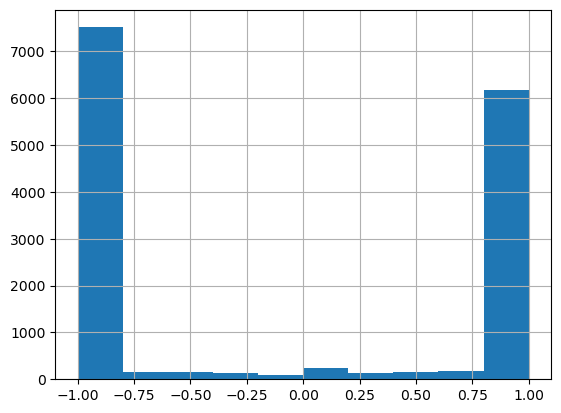

In [13]:
avg_party_tweet_author = notes_party.groupby('noteAuthorParticipantId')['party'].mean()
avg_party_tweet_author.hist()

In [14]:
### Partisanship Signals ###
mask = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') > 1000
avg_party_tweet_author = notes_party[mask].groupby('noteAuthorParticipantId')['party'].mean()


/var/folders/14/04j_x_597gg_sc6gcvkrz1wr0000gp/T/ipykernel_43327/2562596208.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  avg_party_tweet_author_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL')][mask].groupby('raterParticipantId')['party'].mean()
/var/folders/14/04j_x_597gg_sc6gcvkrz1wr0000gp/T/ipykernel_43327/2562596208.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  avg_party_tweet_author_not_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL')][mask].groupby('raterParticipantId')['party'].mean()


<Axes: >

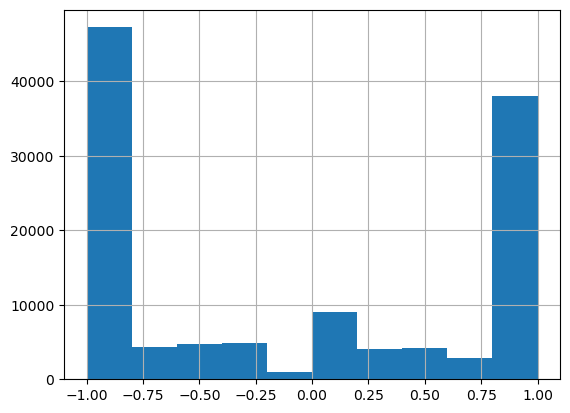

In [15]:

mask = notes_party.groupby('raterParticipantId')['noteId'].transform('count') > 1

avg_party_tweet_author_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL')][mask].groupby('raterParticipantId')['party'].mean()
avg_party_tweet_author_not_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL')][mask].groupby('raterParticipantId')['party'].mean()

avg_party_tweet_author_not_helpful.hist()


/var/folders/14/04j_x_597gg_sc6gcvkrz1wr0000gp/T/ipykernel_43327/1539246585.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  avg_note_factor_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL')][mask].groupby('raterParticipantId')['noteFinalFactor'].mean()
/var/folders/14/04j_x_597gg_sc6gcvkrz1wr0000gp/T/ipykernel_43327/1539246585.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  avg_note_factor_not_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL')][mask].groupby('raterParticipantId')['noteFinalFactor'].mean()


<Axes: >

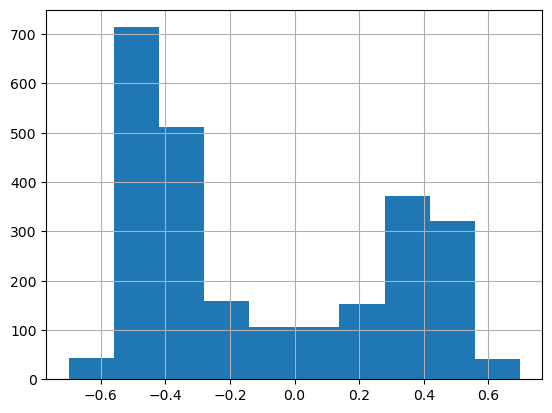

In [16]:
mask = notes_party.groupby('raterParticipantId')['noteId'].transform('count') > 100

avg_note_factor_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL')][mask].groupby('raterParticipantId')['noteFinalFactor'].mean()
avg_note_factor_not_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL')][mask].groupby('raterParticipantId')['noteFinalFactor'].mean()

avg_note_factor_not_helpful.hist()

<Axes: >

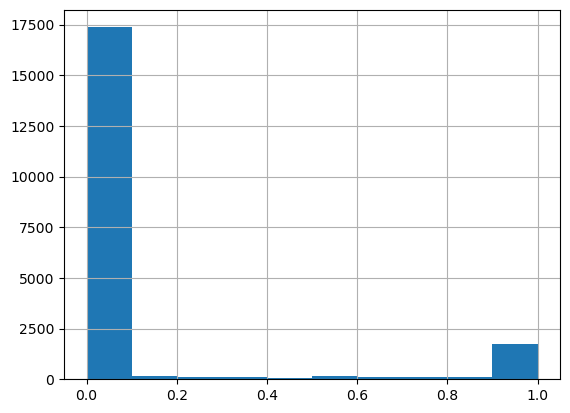

In [17]:
mask = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count')
helpful_notes = notes_party['noteFinalRatingStatus'] == "CURRENTLY_RATED_HELPFUL"
pct_helpful_notes = helpful_notes.groupby(notes_party['noteAuthorParticipantId']).mean()
pct_helpful_notes.hist()

### 5. Do users tend to focus on a single topic, or do they tend to mix topics?

Most contributors who have rated more than one note 

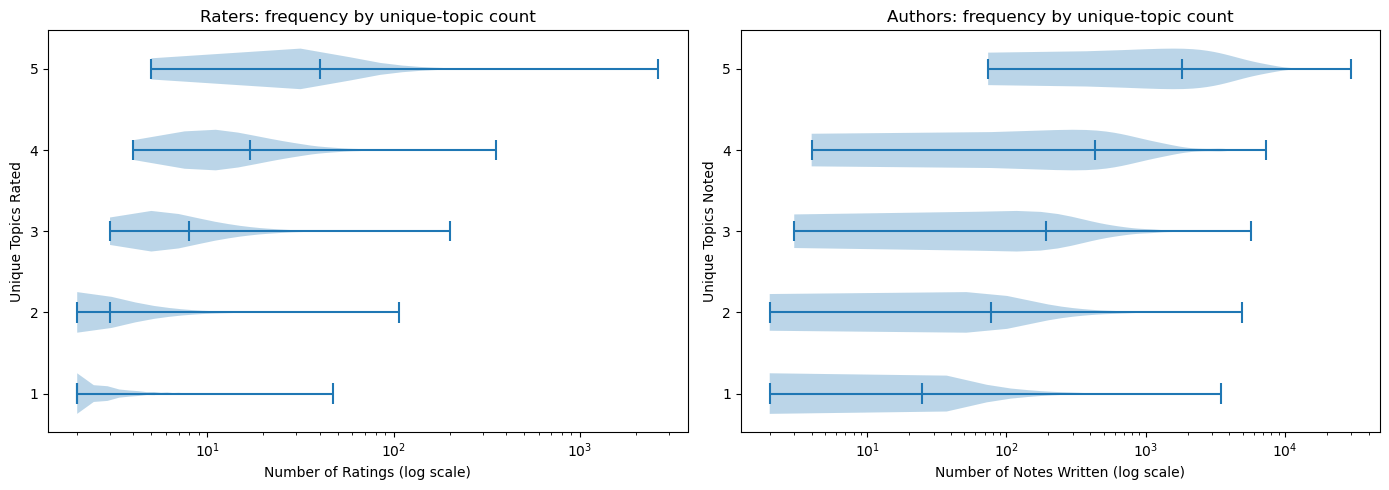

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# filter for raters/authors with multiple contributions
mask_rated = notes_party.groupby('raterParticipantId')['noteId'].transform('count') > 1
num_unique_topics_rated_filtered = notes_party[mask_rated].groupby('raterParticipantId')['topic'].nunique()

mask_noted = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') > 1
num_unique_topics_noted_filtered = notes_party[mask_noted].groupby('noteAuthorParticipantId')['topic'].nunique()

plt.tight_layout()

# build frequency series for each id and pair with the unique‑topic counts
freq_rated = notes_party[mask_rated].groupby('raterParticipantId')['noteId'].count()
freq_noted = notes_party[mask_noted].groupby('noteAuthorParticipantId')['noteId'].count()

df_rated = pd.DataFrame({
    'freq': freq_rated,
    'unique_topics': num_unique_topics_rated_filtered
}).dropna()

df_noted = pd.DataFrame({
    'freq': freq_noted,
    'unique_topics': num_unique_topics_noted_filtered
}).dropna()

# prepare data for violin plots: list of freq arrays for each unique_topics category
cats_r = sorted(df_rated['unique_topics'].unique())
data_r = [df_rated.loc[df_rated['unique_topics'] == c, 'freq'].values for c in cats_r]

cats_n = sorted(df_noted['unique_topics'].unique())
data_n = [df_noted.loc[df_noted['unique_topics'] == c, 'freq'].values for c in cats_n]

# horizontal violin plots (swap axes) with log x-scale
parts = axes[0].violinplot(data_r, showmeans=False, showmedians=True, vert=False, positions=range(1, len(cats_r) + 1))
axes[0].set_yticks(range(1, len(cats_r) + 1))
axes[0].set_yticklabels(cats_r)
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Ratings (log scale)')
axes[0].set_ylabel('Unique Topics Rated')
axes[0].set_title('Raters: frequency by unique-topic count')

parts = axes[1].violinplot(data_n, showmeans=False, showmedians=True, vert=False, positions=range(1, len(cats_n) + 1))
axes[1].set_yticks(range(1, len(cats_n) + 1))
axes[1].set_yticklabels(cats_n)
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Notes Written (log scale)')
axes[1].set_ylabel('Unique Topics Noted')
axes[1].set_title('Authors: frequency by unique-topic count')

plt.tight_layout()

### 6. What is the relationship between how frequently users contribute and what topics they focus on?

Comparing low-, medium-, and high-frequency note-raters, there is a clear increase in focus on politics-related tweets as rating frequency increases. "science" and "other" seem to decrease as rating frequency increases, and "health" appears to increase a bit. Applying the same analysis to note-writing, we can observe a similar pattern of politics increasing in relative frequency while everything else stays fairly even across contribution frequency, but the change is not nearly as pronounced.

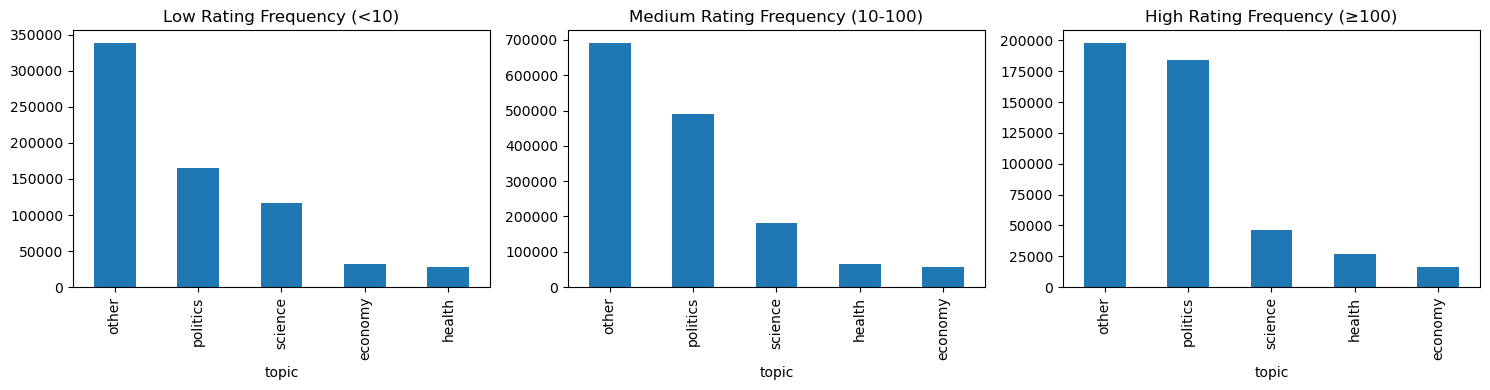

In [21]:
# boolean masks
mask_low = notes_party.groupby('raterParticipantId')['noteId'].transform('count') < 10
mask_mid = (notes_party.groupby('raterParticipantId')['noteId'].transform('count') >= 10) & (notes_party.groupby('raterParticipantId')['noteId'].transform('count') < 100) 
mask_high = notes_party.groupby('raterParticipantId')['noteId'].transform('count') >= 100

# topic counts by contribution frequency
topic_counts_low = notes_party[mask_low]['topic'].value_counts()
topic_counts_mid = notes_party[mask_mid]['topic'].value_counts()
topic_counts_high = notes_party[mask_high]['topic'].value_counts()

# bar plots of topic incidence for raters meeting each threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
topic_counts_low.plot.bar(ax=axes[0], title='Low Rating Frequency (<10)')
topic_counts_mid.plot.bar(ax=axes[1], title='Medium Rating Frequency (10-100)')
topic_counts_high.plot.bar(ax=axes[2], title='High Rating Frequency (≥100)')
plt.tight_layout()

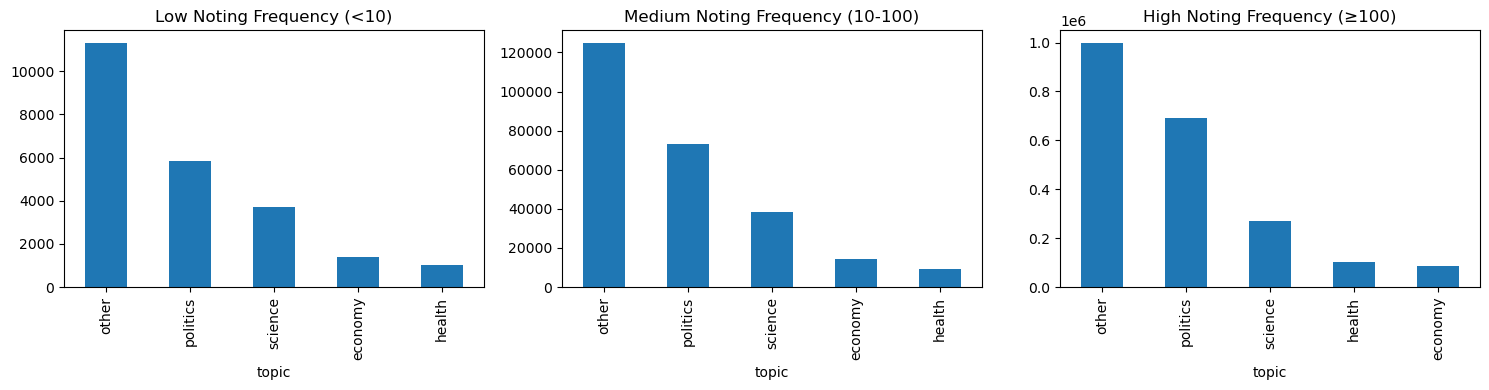

In [20]:
# boolean masks
mask_low = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') < 10
mask_mid = (notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') >= 10) & (notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') < 100) 
mask_high = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') >= 100

# topic counts by contribution frequency
topic_counts_low = notes_party[mask_low]['topic'].value_counts()
topic_counts_mid = notes_party[mask_mid]['topic'].value_counts()
topic_counts_high = notes_party[mask_high]['topic'].value_counts()

# bar plots of topic incidence for authors meeting each threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
topic_counts_low.plot.bar(ax=axes[0], title='Low Noting Frequency (<10)')
topic_counts_mid.plot.bar(ax=axes[1], title='Medium Noting Frequency (10-100)')
topic_counts_high.plot.bar(ax=axes[2], title='High Noting Frequency (≥100)')
plt.tight_layout()

### 7. What is the relationship between how frequently users contribute and their skill?

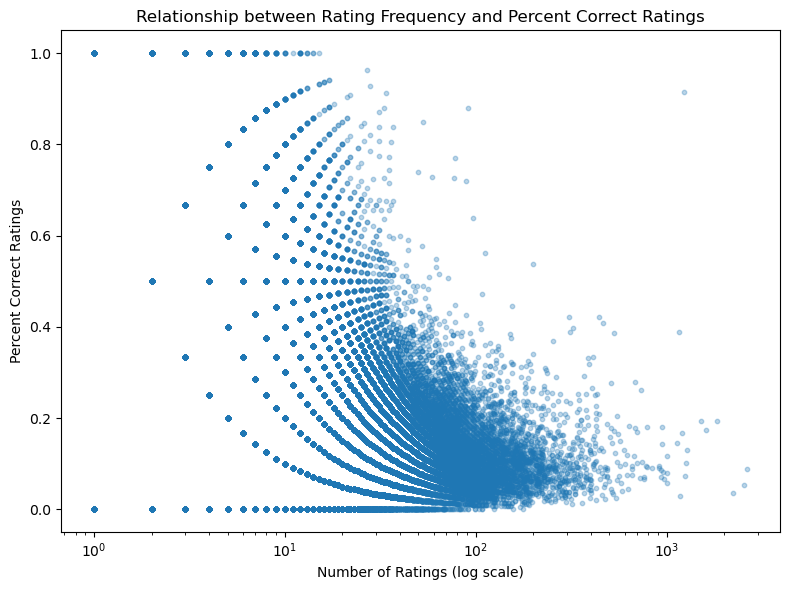

In [ ]:
# rebuild the skill dataframe (in case the previous cell was rerun)
rating_freq = notes_party.groupby('raterParticipantId')['noteId'].count()
df_skill = pd.DataFrame({
    'rating_freq': rating_freq,
    'pct_correct': pct_correct_ratings
}).dropna()

# drop raters with fewer than 10 ratings
df_skill = df_skill[df_skill['rating_freq'] >= 10]

# prepare variables for fit
x = df_skill['rating_freq']
y = df_skill['pct_correct']

# fit on log‑frequency and get correlation
log_x = np.log(x)
m, b = np.polyfit(log_x, y, 1)
r = np.corrcoef(log_x, y)[0, 1]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.3, s=10)

# best‑fit line on original scale
xs = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
plt.plot(xs, m * np.log(xs) + b, color='red', lw=2)

plt.xscale('log')
plt.xlabel('Number of Ratings (log scale)')
plt.ylabel('Percent Correct Ratings')
plt.title(f'Rating frequency vs percent correct (≥10 ratings)  r={r:.3f}')
plt.tight_layout();
plt.show()

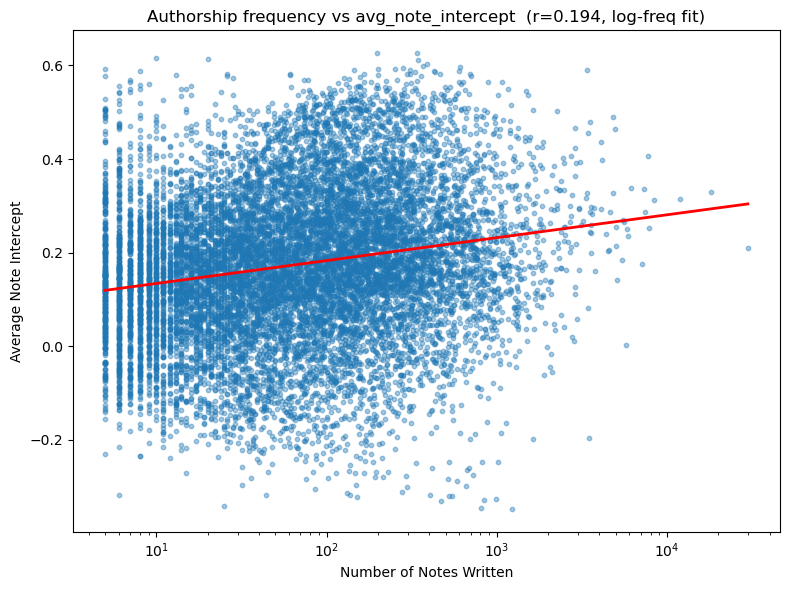

In [44]:
# scatterplot: authorship frequency vs avg_note_intercept with best‑fit line and
# correlation computed on log‑transformed frequency
df_plot = pd.concat([x, y], axis=1).dropna()
df_plot.columns = ['freq', 'avg_intercept']

# exclude users with fewer than 5 notes authored
df_plot = df_plot[df_plot['freq'] >= 5]

# log‑transform the x variable for the regression
log_freq = np.log(df_plot['freq'])

# fit and get correlation on the logged values
m, b = np.polyfit(log_freq, df_plot['avg_intercept'], 1)
r = np.corrcoef(log_freq, df_plot['avg_intercept'])[0, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df_plot['freq'], df_plot['avg_intercept'], s=10, alpha=0.4)

# build xs on the original scale and map them through log for the fit line
xs = np.logspace(np.log10(df_plot['freq'].min()),
                 np.log10(df_plot['freq'].max()), 200)
plt.plot(xs, m * np.log(xs) + b, color='red', lw=2)

plt.xscale('log')                         # log scale on x‑axis
plt.xlabel('Number of Notes Written')
plt.ylabel('Average Note Intercept')
plt.title(f'Authorship frequency vs avg_note_intercept  (r={r:.3f}, log‑freq fit)')
plt.tight_layout()
plt.show()